On s'intéresse à l'EDO sur $[0,3]$
$$
\frac{d^2u}{dt^2} +\pi^2 \sin(\pi t) = 0,\quad u(0)=0=u(3).
$$
On connaît la solution. Les 'datas' sont les résidus de l'équation différentielle et les conditions au bord.

C'est un exemple basique avec des outils basiques.

On se sert d'abord uniquement de **JAX**.
On construit un MLP à la main, dans ```init_params()```

/var/folders/sb/knvybxqx1qj0b6khq7v2_5s80000gn/T/ipykernel_90229/2399028585.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


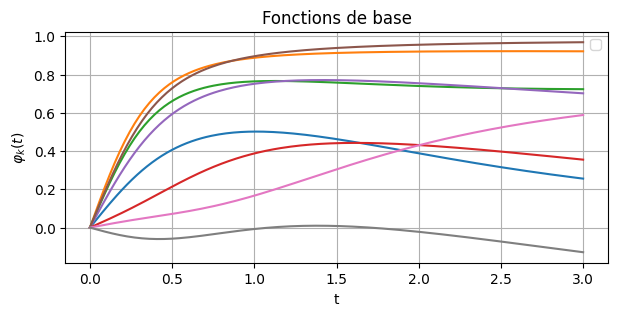

     0    4.686e+01
   300    2.386e+01
   600    2.018e+01
   900    6.927e+00
  1200    5.423e+00
  1500    4.883e+00
  1800    4.558e+00
  2100    4.338e+00
  2400    4.138e+00
  2700    3.794e+00
  3000    1.250e+00
  3300    3.382e-01
  3600    9.367e-02
  3900    4.888e-02
  4200    3.948e-02
  4500    3.527e-02
  4800    3.214e-02
  5100    2.953e-02
  5400    2.728e-02
  5700    2.532e-02


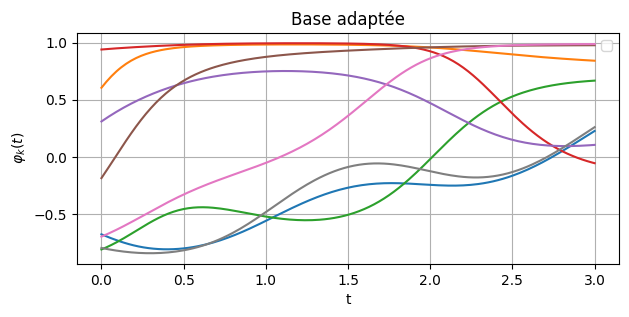

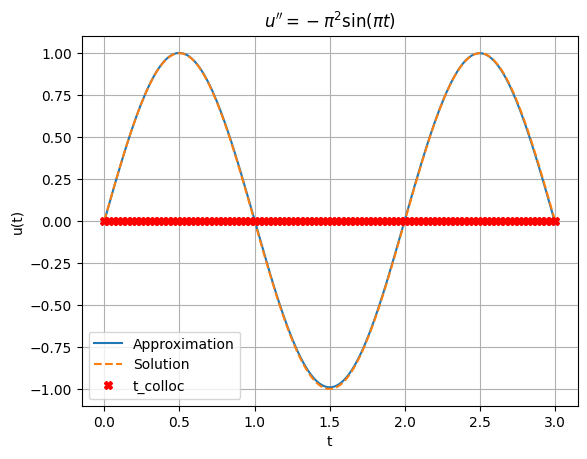

In [ ]:
#
# I - Exemple minimal : intégration de u''(t) = - pi^2 sin(pi t)
#
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np

# Commençons par des fonctions de visuualisation
def plot_solutions(t_plot, t_colloc, u1, u2, t1='Approximation', t2='Solution', ls1='', ls2='--', title=r"$u'' = -\pi^2 \sin(\pi t)$"):
    plt.plot(t_plot, u1, ls1, label=t1)
    plt.plot(t_plot, u2, ls2, label=t2)
    plt.plot(t_colloc, np.zeros_like(t_colloc), 'Xr', label='t_colloc')
    plt.legend()
    plt.xlabel("t")
    plt.ylabel("u(t)")
    plt.title(title)
    plt.grid(True)
    plt.show()
def plot_bases(t_plot, phi, title="Fonctions de base"):
    plt.figure(figsize=(7,3))
    plt.plot(t_plot, phi.T)
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(r"$\varphi_k(t)$")
    plt.grid(True)
    plt.legend()
    plt.show()

# Machine
# Initialisation des paramètres
def init_params(layers):
    key = jax.random.PRNGKey(0)
    key, subkey = jax.random.split(key)
    params = []
    for l in range(1, len(layers)):
        in_dim, out_dim = layers[l-1], layers[l]
        key, subkey = jax.random.split(key)
        W = jax.random.normal(subkey, (out_dim, in_dim)) * jnp.sqrt(2/in_dim)
        b = jnp.zeros(out_dim)
        params.append((W,b))
    return params
def basis(params, t):
    t = jnp.atleast_1d(t).reshape(1, -1)
    for param in params[:-1]:
        W, b = param
        t = jnp.tanh(W @ t + b[:, None])
    return t
def forward(params, t):
    B = basis(params, t)
    W, b = params[-1]
    return (W @ B +b).squeeze()

# Calcul de u''(x) par JAX autodiff
def dudt(params, t):
    return jax.grad(forward, argnums=1)(params, t)
def d2udt2(params, t):
    return jax.grad(dudt, argnums=1)(params, t)
def residual(params, t):
    return d2udt2(params, t) + (jnp.pi ** 2) * jnp.sin(jnp.pi * t)

@jax.jit
def loss(params, t_colloc):
    # ODE loss
    res = jax.vmap(lambda t: residual(params, t))(t_colloc)
    ode_loss = jnp.mean(res ** 2)
    # Boundary conditions
    bc_loss = forward(params, t_colloc[0]) ** 2 + forward(params, t_colloc[-1]) ** 2
    return ode_loss+ bc_loss 

# Une itération de gradient
@jax.jit
def update(params, lr, t_colloc):
    grads = jax.grad(loss)(params, t_colloc)
    return [(W[0] - lr*g[0], W[1] - lr*g[1]) for W, g in zip(params, grads)]


layers = [1, 8, 8, 1]
params = init_params(layers)

t_plot = jnp.linspace(t0, t1, 200)
B = basis(params, t_plot)
plot_bases(t_plot, B)


# Points de collocation
t0, t1, n_colloc = 0, 3, 100
t_colloc = jnp.linspace(t0, t1, n_colloc)


# Boucle d'entraînement
lr, n_epochs = 0.001, 6000
for epoch in range(n_epochs):
    params = update(params, lr=lr, t_colloc=t_colloc)
    if epoch % 300 == 0:
        loss_val = loss(params, t_colloc)
        print(f"{epoch:6d} {loss_val:12.3e}")


# Visu
u_pred = forward(params,t_plot)
u_true = jnp.sin(jnp.pi * t_plot)
B = basis(params, t_plot)
plot_bases(t_plot, B, title="Base adaptée")

plot_solutions(t_plot, t_colloc, u_pred, u_true)

On fait la même chose, mais avec l'implémentation de la méthode de minimisation LBFGS de la bibliothèque **optax**.

/var/folders/sb/knvybxqx1qj0b6khq7v2_5s80000gn/T/ipykernel_90229/2399028585.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


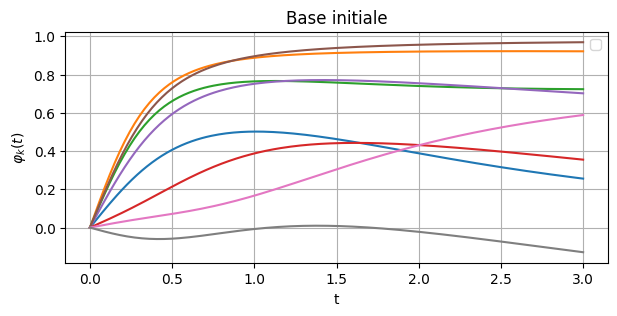

Epoch       0, Loss: 4.769e+01
Epoch      50, Loss: 4.220e+00
Epoch     100, Loss: 7.368e-02
Epoch     150, Loss: 1.591e-02
Epoch     200, Loss: 2.025e-03
Epoch     250, Loss: 1.117e-03


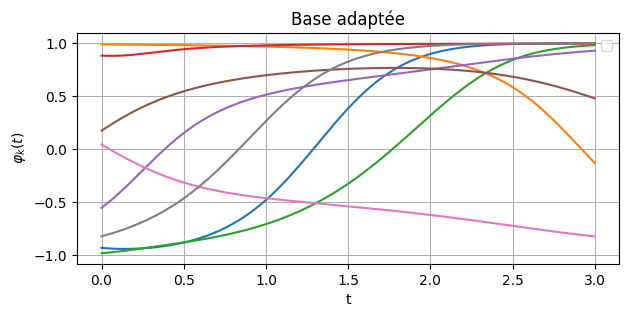

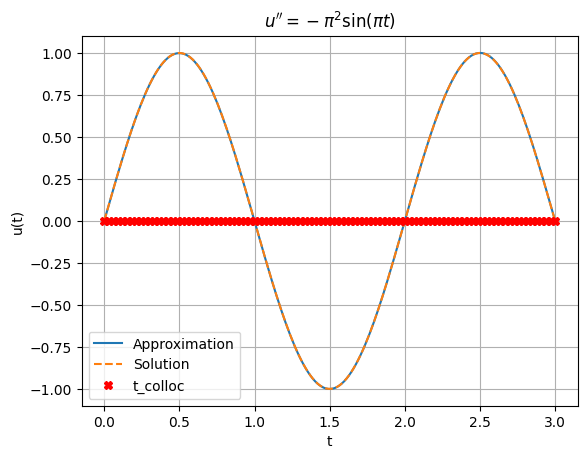

In [ ]:
#
# II - Exemple minimal : avec LBFGS
#

import optax 


# Calcul de u''(x) par JAX autodiff
dudt_scalar = jax.grad(forward, argnums=1)
d2udt2_scalar = jax.grad(dudt_scalar, argnums=1)
dudt = jax.vmap(dudt_scalar, in_axes=(None, 0))
d2udt2 = jax.vmap(d2udt2_scalar, in_axes=(None, 0))

def residual(params, t):
    return d2udt2(params, t) + (jnp.pi ** 2) * jnp.sin(jnp.pi * t)

@jax.jit
def loss(params, t_colloc):
    # Collocation loss
    res = residual(params, t_colloc)
    ode_loss = jnp.mean(res ** 2)
    # Boundary conditions
    bc_loss = forward(params, t_colloc[0]) ** 2 + forward(params, t_colloc[-1]) ** 2
    return ode_loss+ bc_loss 


layers = [1, 8, 8, 1]
params = init_params(layers)
t_plot = jnp.linspace(t0, t1, 200)
B = basis(params, t_plot)
plot_bases(t_plot, B, title="Base initiale")

optimizer = optax.lbfgs(learning_rate=0.01)
opt_state = optimizer.init(params)
@jax.jit
def train_step(params, opt_state, t_colloc):
    loss_fn = lambda p: loss(p, t_colloc) 
    loss_value, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params, value=loss_value, grad=grads, value_fn=loss_fn)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value, grads, updates



t0, t1, n_colloc = 0, 3, 100
t_colloc = jnp.linspace(t0, t1, n_colloc)

# Boucle d'entraînement
n_epochs = 300
for epoch in range(n_epochs):
    params, opt_state, loss_value, grads, updates = train_step(params, opt_state, t_colloc)
    if epoch % 50== 0:
        print(f"Epoch {epoch:7d}, Loss: {loss_value:.3e}")


# Visu
u_pred = forward(params,t_plot)
u_true = jnp.sin(jnp.pi * t_plot)
B = basis(params, t_plot)
plot_bases(t_plot, B, title="Base adaptée")

plot_solutions(t_plot, t_colloc, u_pred, u_true)

Avant de continuer, on écrit une fonction pour la boucle d'apprentissage.

Epoch       0, Loss: 4.769e+01
Epoch     100, Loss: 7.368e-02
Epoch     200, Loss: 2.025e-03
Epoch     300, Loss: 9.804e-04


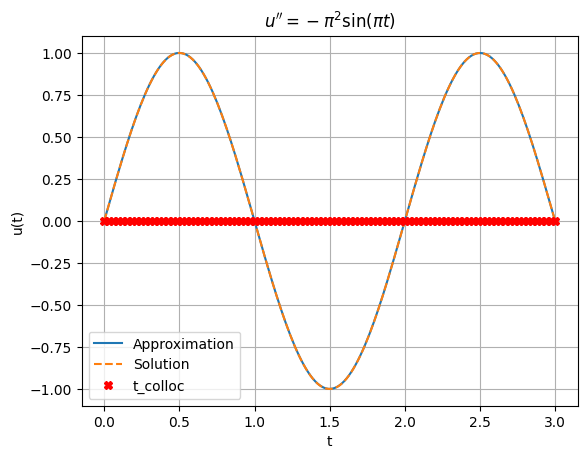

In [ ]:
#
# III - Exemple minimal : fonction d'entraînement
#

import jax
import jax.numpy as jnp
import optax

def train(params, loss, optimizer=None, n_epochs=100, print_every=10, learning_rate=0.1, **kwargs):
    """
    Train parameters using the given optimizer and loss function.
    
    Args:
        params: pytree of parameters to optimize
        loss_fn: function(params) -> scalar loss
        optimizer: optax optimizer instance
        n_epochs: number of training epochs
        print_every: how often to print progress
    
    Returns:
        params: optimized parameters
        opt_state: final optimizer state
    """
    if optimizer is None: optimizer = optax.lbfgs(learning_rate=learning_rate)
   
    # Initialize optimizer state
    opt_state = optimizer.init(params)

    # Define one train step
    @jax.jit
    def train_step(params, opt_state, **kwargs):
        loss_fn = lambda p: loss(p, **kwargs)
        loss_value, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params, value=loss_value, grad=grads, value_fn=loss_fn)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_value, grads, updates

    # Training loop
    for epoch in range(n_epochs):
        params, opt_state, loss_value, grads, updates = train_step(params, opt_state, **kwargs)
        if epoch % print_every == 0:
            print(f"Epoch {epoch:7d}, Loss: {loss_value:.3e}")

    return params, opt_state


# Exemple d'utilisation
params = init_params(layers)
params, opt_state = train(params, loss, learning_rate=0.01, n_epochs=400, print_every=100, t_colloc=t_colloc)

t_plot = jnp.linspace(t0, t1, 200)
u_pred = jax.vmap(lambda t: forward(params,t))(t_plot)
u_true = jnp.sin(jnp.pi * t_plot)

plot_solutions(t_plot, t_colloc, u_pred, u_true)


Ici, on utilise aussi FLAX, ou plutôt sa partie nnx.
Cela ressemble à pytorch dans l'idée, mais le traîtement de paramètres est différent.

Epoch       0, Loss: 4.140e+01
Epoch     100, Loss: 1.704e+00
Epoch     200, Loss: 2.346e-06
Epoch     300, Loss: 2.798e-09


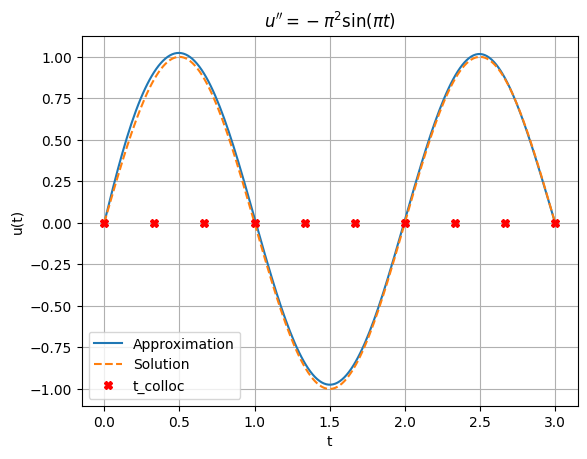

In [ ]:
#
# IV - Exemple minimal : avec Flax.nnx
#
from flax import nnx
class MLP(nnx.Module):
    def __init__(self, layers):
        key = jax.random.PRNGKey(0)
        key, subkey = jax.random.split(key)
        self.layers = []
        for l in range(1,len(layers)):
            in_dim, out_dim =  layers[l-1], layers[l]
            key, subkey = jax.random.split(key)
            layer = nnx.Linear(in_dim, out_dim, rngs=nnx.Rngs(key))
            self.layers.append(layer)
            in_dim = out_dim
    def forward(self, t):
        t = jnp.atleast_1d(t).reshape(1, -1)
        for layer in self.layers[:-1]:
            t = jnp.tanh(layer(t))
        last_layer = self.layers[-1]
        return last_layer(t).squeeze()
    def residual_ode(self, t):
        dudt_scalar = jax.grad(self.forward)
        d2udt2_scalar = jax.grad(dudt_scalar)
        # vmap over t
        return jax.vmap(lambda tau: d2udt2_scalar(tau) + (jnp.pi**2)*jnp.sin(jnp.pi*tau))(t)
    def residual_bc(self, t0, t1):
        return self.forward(t0) **2 + self.forward(t1)**2
    def loss(self, t):
        ode_loss = jnp.mean(self.residual_ode(t)**2)
        bc_loss = self.residual_bc(t[0], t[-1])
        return ode_loss + bc_loss


machine = MLP(layers)
# on récupère tous les ingrédients du 'module'
graphdef, params, batch_stats = nnx.split(machine, nnx.Param, nnx.BatchStat)
@jax.jit
def loss(params, t_colloc):
    # on reconstruit une machine avec les paramètres actuels
    machine_tmp = nnx.merge(graphdef, params, batch_stats)
    return machine_tmp.loss(t_colloc)


params, opt_state = train(params, loss, learning_rate=0.1, n_epochs=400, print_every=100, t_colloc=t_colloc)

# on reconstruit une machine avec les paramètres trouvés
trained_machine = nnx.merge(graphdef, params, batch_stats)
# Visu
t_plot = jnp.linspace(t0, t1, 200)
u_pred = jax.vmap(trained_machine.forward)(t_plot)
u_true = jnp.sin(jnp.pi * t_plot)

plot_solutions(t_plot, t_colloc, u_pred, u_true)


On revient à notre première version, mais pour résoudre une EDO d'ordre un. 
$$
u'(t) = \lambda u(t),\qquad u(0)=u0. 
$$

Epoch       0, Loss: 1.031e+00
Epoch     100, Loss: 3.201e-04
Epoch     200, Loss: 1.304e-05
Epoch     300, Loss: 2.404e-06


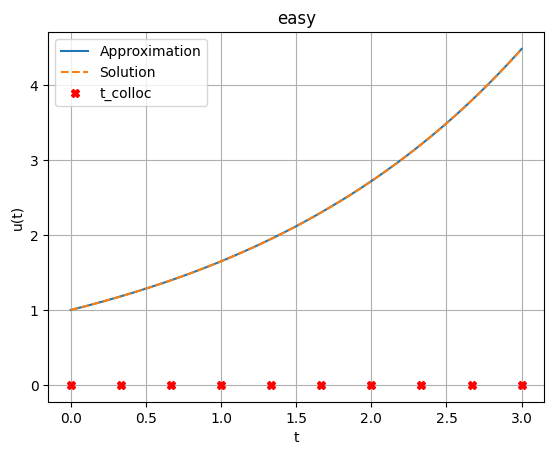

In [224]:
# Points de collocation
t0, t1, n_colloc = 0, 3, 10
t_colloc = jnp.linspace(t0, t1, n_colloc)
#
lam = 0.5
u0 = 1.0
def u(t): return jnp.exp(lam * t)*u0


def residual(params, t):
    return dudt(params, t) - lam*forward(params, t)

# Total loss = ode + boundary conditions
@jax.jit
def loss(params, t_colloc):
    # Physics loss
    res = residual(params, t_colloc)
    ode_loss = jnp.mean(res ** 2)
    # Boundary conditions
    bc_loss = (forward(params, t_colloc[0])-u0) ** 2
    return ode_loss + bc_loss

layers = [1, 8, 8, 1]
params = init_params(layers)
params, opt_state = train(params, loss, learning_rate=0.01, n_epochs=400, print_every=100, t_colloc=t_colloc)

t_plot = jnp.linspace(t0, t1, 200)
u_pred = jax.vmap(lambda t: forward(params,t))(t_plot)
u_true = u(t_plot)

plot_solutions(t_plot, t_colloc, u_pred, u_true, title="easy")

On revient à notre première version, mais pour résoudre une EDO. Changements :
* on utilise un ```dict``` pour les paramètres
* on résoud l'équation $u'=\sin(\lambda u)$ dont la solution est
$$
u(t) = \frac{2}{\lambda}\arctan(K e^{\lambda t}),\quad K = \tan \frac{\lambda u_0}{2}
$$

Epoch       0, Loss: 7.165e+02
Epoch     100, Loss: 1.358e+00
Epoch     200, Loss: 1.280e+00
Epoch     300, Loss: 1.239e+00


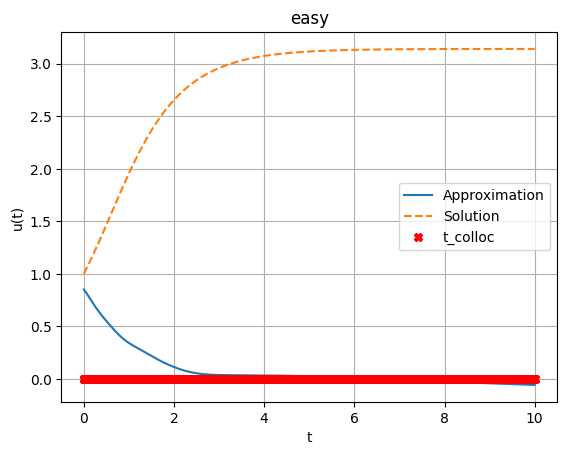

In [205]:
# Points de collocation
t0, t1, n_colloc = 0, 10, 2000
t_colloc = jnp.linspace(t0, t1, n_colloc)
#
lam = 1.0
u0 = 1.0
K = jnp.tan(0.5 * lam * u0)
def u(t): return 2.0/lam*jnp.arctan(K * jnp.exp(lam * t))


def penalty(params, t):
    t = jnp.linspace(t0, t1, layers[-2])
    B = basis(params, t)
    M = B@B.T - jnp.eye(B.shape[0])
    return jnp.sum(M**2)


def residual(params, t):
    return dudt(params, t) - jnp.sin(lam*forward(params, t))

# Total loss = ode + boundary conditions
@jax.jit
def loss(params, t_colloc):
    # Physics loss
    res = residual(params, t_colloc)
    ode_loss = jnp.mean(res ** 2)
    # Boundary conditions
    bc_loss = (forward(params, t_colloc[0])-u0) ** 2
    return ode_loss + bc_loss + 1e-1 * penalty(params, t_colloc)

layers = [1, 16, 16, 1]
params = init_params(layers)
params, opt_state = train(params, loss, learning_rate=0.01, n_epochs=400, print_every=100, t_colloc=t_colloc)

t_plot = jnp.linspace(t0, t1, 200)
u_pred = jax.vmap(lambda t: forward(params,t))(t_plot)
u_true = u(t_plot)

plot_solutions(t_plot, t_colloc, u_pred, u_true, title="easy")